# **Práctica de Calidad de Datos y Minería en Python - Parte Minería de Datos**
## **Integrantes**
- Alfonso Gabriel Jiménez Rivas
- Sebastián Soto Ángel

## **Objetivo del Modelo**
El objetivo es construir un modelo de regresión capaz de predecir el precio de venta (`lastSoldPrice`) de propiedades residenciales en el estado de Arizona, EE.UU.

Los datos provienen de Kaggle, del dataset **"Arizona Real Estate: Sold Properties Dataset 2026"**, el cual contiene 9,954 transacciones residenciales verificadas y cerradas, abarcando 292 códigos ZIP del estado. El volumen total de ventas registrado es de 6.52 billones USD, con un precio mediano de venta de 459,928, y un rango que va desde propiedades de menos de 50K hasta mansiones de lujo que superan los 21 millones.

Cada registro representa una transacción confirmada, no una estimación ni un listado activo, lo que garantiza la calidad y confiabilidad de los datos para entrenar un modelo.

Las variables utilizadas como predictoras son características estructurales de la propiedad: superficie (`sqft`), número de habitaciones (`beds`), baños(`baths`, `baths_full`), espacios de garage (`garage`) y la ubicación geográfica codificada mediante Target Encoding (`zip_encoded`).


### **Importación de Librerías Básicas**

In [77]:
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt # gráfica

### **Carga de Datos**

In [78]:
# Se cargan los datos
data = pd.read_csv("./datos_limpios_arizona.csv")
data.head()

,lastSoldPrice,sqft,beds,baths,baths_full,garage,zip_encoded
0,"4,300,076.00","5,010.00",5.00,6.00,5.00,3.00,"2,463,056.33"
1,"1,750,060.00","4,270.00",5.00,5.00,4.00,3.00,"1,044,502.69"
2,"328,911.00","1,360.00",4.00,2.00,1.00,2.00,"383,021.42"
3,"434,291.00","1,510.00",4.00,2.00,2.00,2.00,"383,021.42"
4,"294,935.00","1,240.00",3.00,2.00,2.00,2.00,"383,021.42"


In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9954 entries, 0 to 9953
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   lastSoldPrice  9954 non-null   float64
 1   sqft           9954 non-null   float64
 2   beds           9954 non-null   float64
 3   baths          9954 non-null   float64
 4   baths_full     9954 non-null   float64
 5   garage         9954 non-null   float64
 6   zip_encoded    9954 non-null   float64
dtypes: float64(7)
memory usage: 544.5 KB


### **Validación Cruzada**
Al crear modelos de regresión, las medidas de evaluación utilizadas fueron:

- **MAE (Mean Absolute Error):** error promedio en dólares entre el precio predicho y
  el real. Es fácil de interpretar porque está en la misma unidad que la variable objetivo.

- **MSE (Mean Squared Error):** penaliza más los errores grandes al elevarlos al cuadrado.
  Útil para detectar predicciones muy alejadas de la realidad.

- **RMSE (Root Mean Squared Error):** es la raíz del MSE, por lo que vuelve a estar en
  dólares y es más interpretable que el MSE, manteniendo la penalización de errores grandes.

- **MAPE (Mean Absolute Percentage Error):** expresa el error como porcentaje del precio
  real, lo que permite evaluar el modelo independientemente de la escala de los precios
  (útil cuando hay propiedades desde $50K hasta $21M).

Se utilizó validación cruzada con **cv=10 folds** para garantizar que los resultados
no dependan de una sola partición de los datos, obteniendo una estimación más robusta
y confiable del desempeño real del modelo.

Las métricas están expresadas en valores negativos (`neg_`) debido a una convención
de Scikit-learn: la librería estandariza todas sus métricas de evaluación bajo el
principio de **"mayor es mejor"**. Como el MAE, MSE y RMSE son errores que se busca
minimizar, Scikit-learn las multiplica por -1 para que internamente pueda tratarlas
como si fueran puntuaciones a maximizar. Al interpretar los resultados simplemente
se ignora el signo negativo.

In [80]:
# Validación Cruzada
from sklearn.model_selection import cross_validate

# Dataframe para comparar los modelos
comparacion_CV=pd.DataFrame()

# Medidas de evaluación
scoring=('neg_mean_absolute_error', 'neg_mean_squared_error','neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error')

# Muestreo lineal
cv=10

In [81]:
# Se separan variables predictoras y objetivo
objetivo = 'lastSoldPrice'

X = data.drop(objetivo, axis = 1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9954 entries, 0 to 9953
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sqft         9954 non-null   float64
 1   beds         9954 non-null   float64
 2   baths        9954 non-null   float64
 3   baths_full   9954 non-null   float64
 4   garage       9954 non-null   float64
 5   zip_encoded  9954 non-null   float64
dtypes: float64(6)
memory usage: 466.7 KB


## **Métodos de Minería Predictiva**

### **Árbol de Decisión (Decision Tree Regressor)**
Se entrenó un árbol de decisión con los siguientes hiperparámetros:

- **criterion='squared_error':** el árbol minimiza el error cuadrático en cada
  división, adecuado para problemas de regresión.
- **min_samples_leaf=35:** cada hoja del árbol debe tener al menos 35 muestras,
  evitando que el modelo memorice casos individuales.
- **max_depth=15:** se limita la profundidad del árbol a 15 niveles para reducir el overfitting, tras probar que valores menores causaban underfitting y valores mayores memorización excesiva de los datos de entrenamiento.

In [82]:
# Decision Tree Regressor
from sklearn import tree
modelTree = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=35, max_depth=15)

In [83]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores= pd.DataFrame(scores) # Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.02,0.00,"-153,976.67","-164,623.86","-117,482,767,045.93","-707,672,499,651.05","-342,757.59","-841,232.73",-0.21,-0.24
1,0.02,0.00,"-190,148.63","-160,989.48","-240,166,185,010.71","-702,409,214,297.34","-490,067.53","-838,098.57",-0.22,-0.24
2,0.02,0.00,"-151,175.33","-163,412.51","-105,060,543,767.02","-706,447,502,563.22","-324,130.44","-840,504.31",-0.24,-0.23
3,0.02,0.00,"-141,295.28","-165,070.45","-137,106,057,489.01","-706,723,009,834.25","-370,278.35","-840,668.19",-0.23,-0.23
4,0.02,0.00,"-168,835.63","-163,744.91","-147,216,907,693.86","-707,114,130,769.11","-383,688.56","-840,900.79",-0.28,-0.23
5,0.02,0.00,"-174,149.68","-159,799.69","-192,586,514,844.34","-697,895,883,853.42","-438,846.80","-835,401.63",-0.25,-0.23
6,0.02,0.00,"-225,945.06","-147,226.08","-5,357,503,774,133.17","-150,773,781,723.52","-2,314,628.22","-388,296.00",-0.27,-0.22
7,0.02,0.00,"-160,789.32","-163,212.47","-172,295,991,047.49","-702,977,683,856.56","-415,085.52","-838,437.64",-0.25,-0.23
8,0.02,0.00,"-180,372.89","-160,570.08","-296,706,235,112.01","-691,672,719,415.41","-544,707.48","-831,668.64",-0.25,-0.23
9,0.02,0.00,"-174,206.61","-161,804.29","-307,490,015,136.35","-686,491,230,220.50","-554,517.82","-828,547.66",-0.29,-0.23


In [84]:
'''
Se promedian los resultados de los 10 folds para obtener una estimación global del
desempeño del modelo. Para detectar overfitting se comparan las métricas de
entrenamiento (train) vs prueba (test) — una diferencia mayor a 5 puntos porcentuales
en el MAPE es señal de que el modelo está memorizando los datos de entrenamiento en
lugar de generalizar. Para este caso, con max_depth=15 se logró mantenerse dentro
de ese límite: MAPE train=5% vs MAPE test=10%.
'''
scores.mean()

,0
fit_time,0.02
score_time,0.00
test_neg_mean_absolute_error,"-172,089.51"
train_neg_mean_absolute_error,"-161,045.38"
test_neg_mean_squared_error,"-707,361,499,127.99"
train_neg_mean_squared_error,"-646,017,765,618.44"
test_neg_root_mean_squared_error,"-617,870.83"
train_neg_root_mean_squared_error,"-792,375.62"
test_neg_mean_absolute_percentage_error,-0.25
train_neg_mean_absolute_percentage_error,-0.23


In [85]:
# Se almacena en el df la medida a comparar
comparacion_CV['Tree']=scores['test_neg_mean_absolute_percentage_error']
comparacion_CV

,Tree
0,-0.21
1,-0.22
2,-0.24
3,-0.23
4,-0.28
5,-0.25
6,-0.27
7,-0.25
8,-0.25
9,-0.29


### **Random Forest Regressor**
Se entrenó un Random Forest con los siguientes hiperparámetros:
- **n_estimators=300:** el modelo construye 300 árboles de decisión independientes
  y promedia sus predicciones, reduciendo la varianza respecto a un solo árbol.
- **max_samples=0.9:** cada árbol se entrena con el 90% de los datos muestreados
  aleatoriamente, introduciendo diversidad entre los árboles y reduciendo el overfitting.
- **criterion='squared_error':** cada árbol minimiza el error cuadrático en cada
  división, adecuado para problemas de regresión.
- **min_samples_leaf=10:** cada hoja debe tener al menos 10 muestras, evitando que los árboles memoricen casos individuales.
- **max_depth=40:** se limita el crecimiento del árbol a profundidad 40. De igual forma, se espera que el efecto de ensemble entre 300 árboles controla el overfitting de forma natural.

In [86]:
# Random forest
from sklearn import ensemble
modelRf = ensemble.RandomForestRegressor(n_estimators=300, max_samples=0.9, criterion='squared_error', min_samples_leaf=10, max_depth=40)

In [87]:
# Validación cruzada
scores = cross_validate(modelRf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,4.35,0.07,"-141,946.16","-139,247.05","-103,748,503,163.57","-629,666,867,654.89","-322,100.14","-793,515.51",-0.19,-0.21
1,5.22,0.07,"-156,462.89","-138,195.13","-128,392,660,299.93","-627,511,748,569.32","-358,319.22","-792,156.39",-0.20,-0.21
2,4.27,0.08,"-145,706.16","-139,394.06","-115,497,648,112.52","-628,985,668,292.15","-339,849.45","-793,086.17",-0.23,-0.20
3,4.34,0.10,"-123,994.33","-140,870.39","-121,173,134,267.10","-624,015,136,357.70","-348,099.32","-789,946.29",-0.21,-0.21
4,4.98,0.07,"-144,867.98","-138,791.15","-105,663,309,374.51","-625,779,604,144.72","-325,058.93","-791,062.33",-0.26,-0.20
5,4.23,0.07,"-166,429.02","-136,268.38","-189,886,832,652.23","-626,076,076,309.74","-435,760.06","-791,249.69",-0.24,-0.20
6,5.05,0.11,"-217,745.11","-123,884.80","-5,351,387,005,462.93","-103,194,607,496.33","-2,313,306.51","-321,239.17",-0.26,-0.19
7,4.28,0.07,"-148,712.89","-138,199.83","-147,938,608,577.42","-624,347,199,981.30","-384,627.88","-790,156.44",-0.23,-0.20
8,4.25,0.07,"-166,610.41","-135,666.35","-228,265,103,698.62","-617,112,495,577.22","-477,770.97","-785,565.08",-0.24,-0.20
9,8.41,0.07,"-155,559.46","-138,017.35","-231,443,795,630.93","-622,817,911,726.44","-481,086.06","-789,188.13",-0.27,-0.20


In [88]:
scores.mean()

,0
fit_time,4.94
score_time,0.08
test_neg_mean_absolute_error,"-156,803.44"
train_neg_mean_absolute_error,"-136,853.45"
test_neg_mean_squared_error,"-672,339,660,123.98"
train_neg_mean_squared_error,"-572,950,731,610.98"
test_neg_root_mean_squared_error,"-578,597.85"
train_neg_root_mean_squared_error,"-743,716.52"
test_neg_mean_absolute_percentage_error,-0.23
train_neg_mean_absolute_percentage_error,-0.20


In [89]:
# Se almacena en el df la medida a comparar
comparacion_CV['RF']=scores['test_neg_mean_absolute_percentage_error']
comparacion_CV

,Tree,RF
0,-0.21,-0.19
1,-0.22,-0.20
2,-0.24,-0.23
3,-0.23,-0.21
4,-0.28,-0.26
5,-0.25,-0.24
6,-0.27,-0.26
7,-0.25,-0.23
8,-0.25,-0.24
9,-0.29,-0.27


### **KNN**
Se entrenó un modelo de K-Nearest-Neighbor con los siguientes hiperparámetros:
- **n_neighbors=8:** el modelo tiene en consideración a 8 de sus vecinos para realizar el cálculo de la predicción.
- **metric='manhattan':** ésta métrica calcula la distancia entre nodos como la suma de la distancia entre las coordenadas verticales y horizontales de los puntos.
- **weights='uniform':** todos los nodos tienen el mismo peso en la predicción, sin discriminar por la distancia entre estos y el nodo a calcular.

In [90]:
# Variables predictoras numéricas
predictoras_numericas = ['sqft', 'beds', 'baths', 'baths_full', 'garage', 'zip_encoded']

In [91]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

min_max_scaler.fit(X[predictoras_numericas]) #Ajuste de los parametros: max - min
X[predictoras_numericas]= min_max_scaler.transform(X[predictoras_numericas])
X.head()

,sqft,beds,baths,baths_full,garage,zip_encoded
0,0.27,0.45,0.38,0.27,0.13,0.41
1,0.23,0.45,0.31,0.20,0.13,0.14
2,0.07,0.36,0.12,0.00,0.07,0.02
3,0.08,0.36,0.12,0.07,0.07,0.02
4,0.06,0.27,0.12,0.07,0.07,0.02


In [92]:
from sklearn.pipeline import Pipeline

#Método Perezoso
from sklearn.neighbors import KNeighborsRegressor
model_knn = KNeighborsRegressor(n_neighbors=8, metric='manhattan', weights='uniform')

pipeline = Pipeline([
    #("preprocessing", preprocessor),
    ("modelKnn", model_knn)
])

In [93]:
scores = cross_validate(pipeline, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores)
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,0.01,0.03,"-155,088.42","-147,337.12","-233,895,331,581.74","-618,079,415,024.06","-483,627.27","-786,180.27",-0.20,-0.21
1,0.01,0.03,"-172,770.28","-145,976.64","-317,009,605,416.57","-613,124,550,644.03","-563,036.06","-783,022.70",-0.22,-0.21
2,0.01,0.03,"-171,665.28","-148,401.68","-338,306,810,470.32","-637,079,801,031.95","-581,641.48","-798,172.79",-0.26,-0.21
3,0.01,0.03,"-128,876.25","-148,992.36","-108,156,610,714.73","-624,154,316,443.14","-328,871.72","-790,034.38",-0.21,-0.21
4,0.01,0.03,"-149,233.19","-148,439.15","-95,829,629,746.73","-631,160,980,133.97","-309,563.61","-794,456.41",-0.25,-0.21
5,0.01,0.04,"-178,811.19","-146,800.83","-307,841,836,926.03","-627,468,158,793.88","-554,834.96","-792,128.88",-0.24,-0.21
6,0.01,0.03,"-224,736.65","-131,694.68","-5,293,404,796,665.42","-114,781,570,557.44","-2,300,740.05","-338,794.29",-0.26,-0.20
7,0.01,0.03,"-155,432.33","-147,483.17","-240,210,681,591.65","-618,625,678,632.78","-490,112.93","-786,527.61",-0.24,-0.21
8,0.01,0.03,"-187,675.76","-144,068.33","-329,228,313,115.62","-613,666,323,936.28","-573,784.20","-783,368.57",-0.25,-0.21
9,0.01,0.02,"-172,828.47","-149,913.57","-388,084,882,822.36","-638,114,239,768.67","-622,964.59","-798,820.53",-0.27,-0.21


In [94]:
# Promedios para verificar overfitting comparando medida de train y test
scores.mean()

,0
fit_time,0.01
score_time,0.03
test_neg_mean_absolute_error,"-169,711.78"
train_neg_mean_absolute_error,"-145,910.75"
test_neg_mean_squared_error,"-765,196,849,905.12"
train_neg_mean_squared_error,"-573,625,503,496.62"
test_neg_root_mean_squared_error,"-680,917.69"
train_neg_root_mean_squared_error,"-745,150.64"
test_neg_mean_absolute_percentage_error,-0.24
train_neg_mean_absolute_percentage_error,-0.21


In [95]:
# Se almacena en el df la medida a comparar
comparacion_CV['Knn']=scores['test_neg_mean_absolute_percentage_error']
print(comparacion_CV)

   Tree    RF   Knn
0 -0.21 -0.19 -0.20
1 -0.22 -0.20 -0.22
2 -0.24 -0.23 -0.26
3 -0.23 -0.21 -0.21
4 -0.28 -0.26 -0.25
5 -0.25 -0.24 -0.24
6 -0.27 -0.26 -0.26
7 -0.25 -0.23 -0.24
8 -0.25 -0.24 -0.25
9 -0.29 -0.27 -0.27


### **Red Neuronal**

Se entrenó un modelo de red neuronal con los siguientes parámetros:

- **activation='relu':** se utiliza la función de activación Rectified Linear Unit (ReLU), la cual transforma las entradas negativas en cero y mantiene las positivas, permitiendo introducir no linealidad en la red.
- **hidden_layer_sizes=(30):** la red neuronal cuenta con una capa oculta compuesta por 30 neuronas.
- **learning_rate='adaptive':** la tasa de aprendizaje se ajusta automáticamente durante el entrenamiento, disminuyendo cuando el modelo deja de mejorar.
- **learning_rate_init=0.2:** establece el valor inicial de la tasa de aprendizaje utilizada durante el proceso de optimización.
- **momentum=0.3:** incorpora una fracción de la actualización previa de los pesos para suavizar el proceso de aprendizaje y reducir oscilaciones.
- **max_iter=500:** define un máximo de 500 iteraciones o épocas de entrenamiento para el modelo.
- **verbose=False:** desactiva la impresión de mensajes de progreso y detalles del entrenamiento en consola.

In [96]:
#Red neuronal
from sklearn.neural_network import MLPRegressor
model_rn = MLPRegressor(activation="relu",hidden_layer_sizes=(30), learning_rate='adaptive',
                     learning_rate_init=0.2, momentum= 0.3, max_iter=500, verbose=False)

pipeline = Pipeline([
    #("preprocessing", preprocessor),
    ("modelRn", model_rn)
])

In [97]:
scores = cross_validate(pipeline, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores)
scores

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,8.35,0.01,"-162,752.15","-175,431.81","-125,728,359,231.43","-728,085,597,914.22","-354,581.95","-853,279.32",-0.22,-0.27
1,11.04,0.01,"-171,887.39","-180,127.86","-129,124,604,541.70","-733,048,939,751.60","-359,339.12","-856,182.77",-0.24,-0.28
2,11.62,0.01,"-154,606.85","-174,872.84","-95,102,838,704.33","-731,083,356,424.62","-308,387.48","-855,034.13",-0.25,-0.27
3,8.59,0.01,"-147,605.24","-177,756.25","-141,504,702,156.91","-726,311,688,372.32","-376,171.11","-852,239.22",-0.24,-0.27
4,11.08,0.01,"-160,325.57","-176,869.00","-105,319,999,909.04","-733,379,385,740.48","-324,530.43","-856,375.73",-0.30,-0.26
5,11.03,0.01,"-184,742.44","-170,114.20","-229,941,101,891.18","-715,881,843,643.09","-479,521.74","-846,098.01",-0.27,-0.26
6,10.58,0.01,"-240,871.24","-159,271.88","-5,335,017,387,758.96","-145,708,349,305.39","-2,309,765.66","-381,717.63",-0.30,-0.25
7,10.37,0.01,"-157,647.68","-176,426.58","-138,361,725,759.69","-727,837,498,935.22","-371,970.06","-853,133.93",-0.27,-0.27
8,10.39,0.01,"-200,442.00","-173,933.06","-320,176,854,957.03","-711,298,849,944.37","-565,841.72","-843,385.35",-0.28,-0.27
9,8.87,0.00,"-171,174.15","-174,488.33","-159,713,395,570.30","-725,590,593,130.37","-399,641.58","-851,816.06",-0.30,-0.26


In [98]:
scores.mean()

,0
fit_time,10.19
score_time,0.01
test_neg_mean_absolute_error,"-175,205.47"
train_neg_mean_absolute_error,"-173,929.18"
test_neg_mean_squared_error,"-677,999,097,048.06"
train_neg_mean_squared_error,"-667,822,610,316.17"
test_neg_root_mean_squared_error,"-584,975.09"
train_neg_root_mean_squared_error,"-804,926.21"
test_neg_mean_absolute_percentage_error,-0.27
train_neg_mean_absolute_percentage_error,-0.27


In [99]:
# Se almacena en el df la medida a comparar
comparacion_CV['Nn']=scores['test_neg_mean_absolute_percentage_error']
comparacion_CV

,Tree,RF,Knn,Nn
0,-0.21,-0.19,-0.20,-0.22
1,-0.22,-0.20,-0.22,-0.24
2,-0.24,-0.23,-0.26,-0.25
3,-0.23,-0.21,-0.21,-0.24
4,-0.28,-0.26,-0.25,-0.30
5,-0.25,-0.24,-0.24,-0.27
6,-0.27,-0.26,-0.26,-0.30
7,-0.25,-0.23,-0.24,-0.27
8,-0.25,-0.24,-0.25,-0.28
9,-0.29,-0.27,-0.27,-0.30


### **SVM**

Se entrenó un modelo de Support Vector Machine para regresión (Support Vector Regressor, SVR) con los siguientes hiperparámetros:


- **kernel='poly':** se utiliza un kernel polinómico, el cual permite modelar relaciones no lineales transformando los datos a un espacio de mayor dimensionalidad.


- **C=55:** se escoge un margen de separación de 55.

In [100]:
#SVM
from sklearn.svm import SVR
model_svm = SVR(kernel='poly',C=55) #'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'

pipeline = Pipeline([
    #("preprocessing", preprocessor),
    ("modelSvm", model_svm)
])

In [101]:
scores = cross_validate(model_svm, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error
0,3.81,0.37,"-175,179.49","-191,313.50","-216,099,831,402.06","-944,765,968,097.62","-464,865.39","-971,990.72",-0.22,-0.27
1,3.40,0.20,"-187,733.36","-190,311.42","-175,643,864,181.76","-948,213,400,359.03","-419,098.87","-973,762.50",-0.23,-0.27
2,3.36,0.20,"-166,414.33","-192,150.16","-152,501,134,066.63","-948,083,167,960.67","-390,513.94","-973,695.62",-0.24,-0.27
3,3.98,0.20,"-139,861.51","-194,816.60","-153,514,819,362.41","-970,613,632,404.52","-391,809.67","-985,197.26",-0.23,-0.27
4,3.34,0.20,"-178,683.63","-190,699.18","-135,185,089,518.60","-955,061,081,291.97","-367,675.25","-977,272.27",-0.30,-0.27
5,3.40,0.22,"-195,101.31","-189,093.47","-247,011,721,462.18","-939,787,124,114.59","-497,002.74","-969,426.18",-0.28,-0.27
6,3.36,0.20,"-259,314.19","-182,160.28","-5,449,294,075,378.36","-370,039,027,606.30","-2,334,372.31","-608,308.33",-0.32,-0.27
7,3.92,0.20,"-165,605.11","-192,349.52","-129,217,546,717.77","-951,750,640,823.08","-359,468.42","-975,577.08",-0.28,-0.27
8,4.16,0.20,"-211,202.49","-187,483.46","-336,872,718,106.50","-927,677,262,290.68","-580,407.37","-963,160.04",-0.28,-0.27
9,3.74,0.22,"-234,377.79","-183,717.42","-2,668,600,174,480.79","-772,210,028,978.42","-1,633,585.07","-878,754.82",-0.31,-0.26


In [102]:
scores.mean()

,0
fit_time,3.65
score_time,0.22
test_neg_mean_absolute_error,"-191,347.32"
train_neg_mean_absolute_error,"-189,409.50"
test_neg_mean_squared_error,"-966,394,097,467.70"
train_neg_mean_squared_error,"-872,820,133,392.69"
test_neg_root_mean_squared_error,"-743,879.90"
train_neg_root_mean_squared_error,"-927,714.48"
test_neg_mean_absolute_percentage_error,-0.27
train_neg_mean_absolute_percentage_error,-0.27


In [103]:
# Se almacena en el df la medida a comparar
comparacion_CV['SVM']=scores['test_neg_mean_absolute_percentage_error']
comparacion_CV

,Tree,RF,Knn,Nn,SVM
0,-0.21,-0.19,-0.20,-0.22,-0.22
1,-0.22,-0.20,-0.22,-0.24,-0.23
2,-0.24,-0.23,-0.26,-0.25,-0.24
3,-0.23,-0.21,-0.21,-0.24,-0.23
4,-0.28,-0.26,-0.25,-0.30,-0.30
5,-0.25,-0.24,-0.24,-0.27,-0.28
6,-0.27,-0.26,-0.26,-0.30,-0.32
7,-0.25,-0.23,-0.24,-0.27,-0.28
8,-0.25,-0.24,-0.25,-0.28,-0.28
9,-0.29,-0.27,-0.27,-0.30,-0.31


# **Selección del Modelo**

In [104]:
comparacion_CV

,Tree,RF,Knn,Nn,SVM
0,-0.21,-0.19,-0.20,-0.22,-0.22
1,-0.22,-0.20,-0.22,-0.24,-0.23
2,-0.24,-0.23,-0.26,-0.25,-0.24
3,-0.23,-0.21,-0.21,-0.24,-0.23
4,-0.28,-0.26,-0.25,-0.30,-0.30
5,-0.25,-0.24,-0.24,-0.27,-0.28
6,-0.27,-0.26,-0.26,-0.30,-0.32
7,-0.25,-0.23,-0.24,-0.27,-0.28
8,-0.25,-0.24,-0.25,-0.28,-0.28
9,-0.29,-0.27,-0.27,-0.30,-0.31


<Axes: >

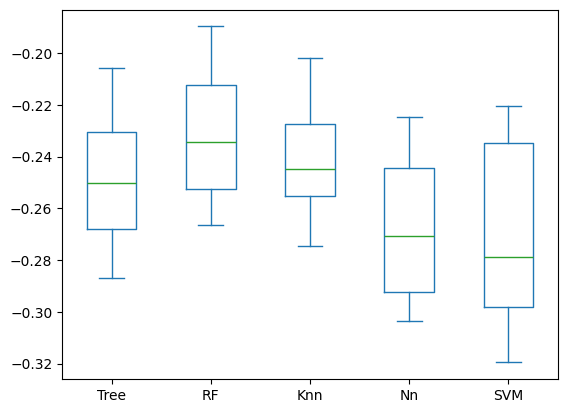

In [105]:
#Resultados de la validación cruzada
comparacion_CV.plot(kind='box')

Se evidencia que Random Forest es el modelo que obtiene los mejores resultados de forma consistente contra las iteraciones de k-fold.

# **Hiperparametrización para RF**

In [106]:
# Hiperparametrización
from sklearn.model_selection import GridSearchCV
cv=10

In [107]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

model_rf = RandomForestRegressor(random_state=1)

# RF params
n_estimators        = [200, 300]
max_samples         = [0.8, 0.9]
max_depth           = [10, 20, 30]
min_samples_leaf    = [10, 30, 40]
criterion           = ['squared_error']

param_grid = dict(
    n_estimators     = n_estimators,
    max_samples      = max_samples,
    max_depth        = max_depth,
    min_samples_leaf = min_samples_leaf,
    criterion        = criterion
)

grid = GridSearchCV(
    estimator = model_rf,
    param_grid = param_grid,
    scoring = 'neg_mean_absolute_percentage_error',
    n_jobs = -1,
    cv = cv
)
grid.fit(X, Y)

# Mejor modelo
model_rf = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'squared_error', 'max_depth': 30, 'max_samples': 0.9, 'min_samples_leaf': 10, 'n_estimators': 300}
-0.23157490550067653


Se encuentra que los parámetros que generan el mejor desempeño del modelo son los siguientes:

- **criterion='squared_error':** utiliza el error cuadrático como criterio para medir la calidad de las divisiones realizadas en los árboles del bosque aleatorio.

- **max_depth=30:** establece una profundidad máxima de 30 niveles para cada árbol del modelo.

- **max_samples=0.9:** cada árbol es entrenado utilizando el 90% de las muestras disponibles del conjunto de datos.

- **min_samples_leaf=10:** cada nodo hoja debe contener al menos 10 muestras para evitar particiones demasiado pequeñas.

- **n_estimators=300:** el modelo está compuesto por 300 árboles de decisión entrenados de manera conjunta.

Logrando un valor de error medio absoluto porcentual de 22,5%.

## **Guardar el Modelo de RF**

In [108]:
import pickle
filename = 'modelo.pkl'
variables= X.columns._values
pickle.dump([model_rf,variables,min_max_scaler], open(filename, 'wb')) #write